<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/LAB_Decision_Tree_HQ_SE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DECISION TREE**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# **Decision Tree for Regreesion**

## **CPU Machine Dataset**

In [6]:
machine_cpu = fetch_openml(name='machine_cpu', version=1)
cpu_X, cpu_y = machine_cpu.data, machine_cpu.target
cpu_feature_names = machine_cpu.feature_names

In [7]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [8]:
cpu_df = pd.DataFrame(cpu_X, columns=cpu_feature_names)
cpu_df["performance"] = cpu_y

# Hiển thị thông tin
display(cpu_df.head())
print(f"Kích thước dữ liệu: {cpu_df.shape}")
print(f"Các đặc trưng: {list(cpu_feature_names)}")
print("Target: Performance (CPU Relative Performance)")
cpu_df.info()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,performance
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132


Kích thước dữ liệu: (209, 7)
Các đặc trưng: ['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']
Target: Performance (CPU Relative Performance)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   MYCT         209 non-null    int64
 1   MMIN         209 non-null    int64
 2   MMAX         209 non-null    int64
 3   CACH         209 non-null    int64
 4   CHMIN        209 non-null    int64
 5   CHMAX        209 non-null    int64
 6   performance  209 non-null    int64
dtypes: int64(7)
memory usage: 11.6 KB


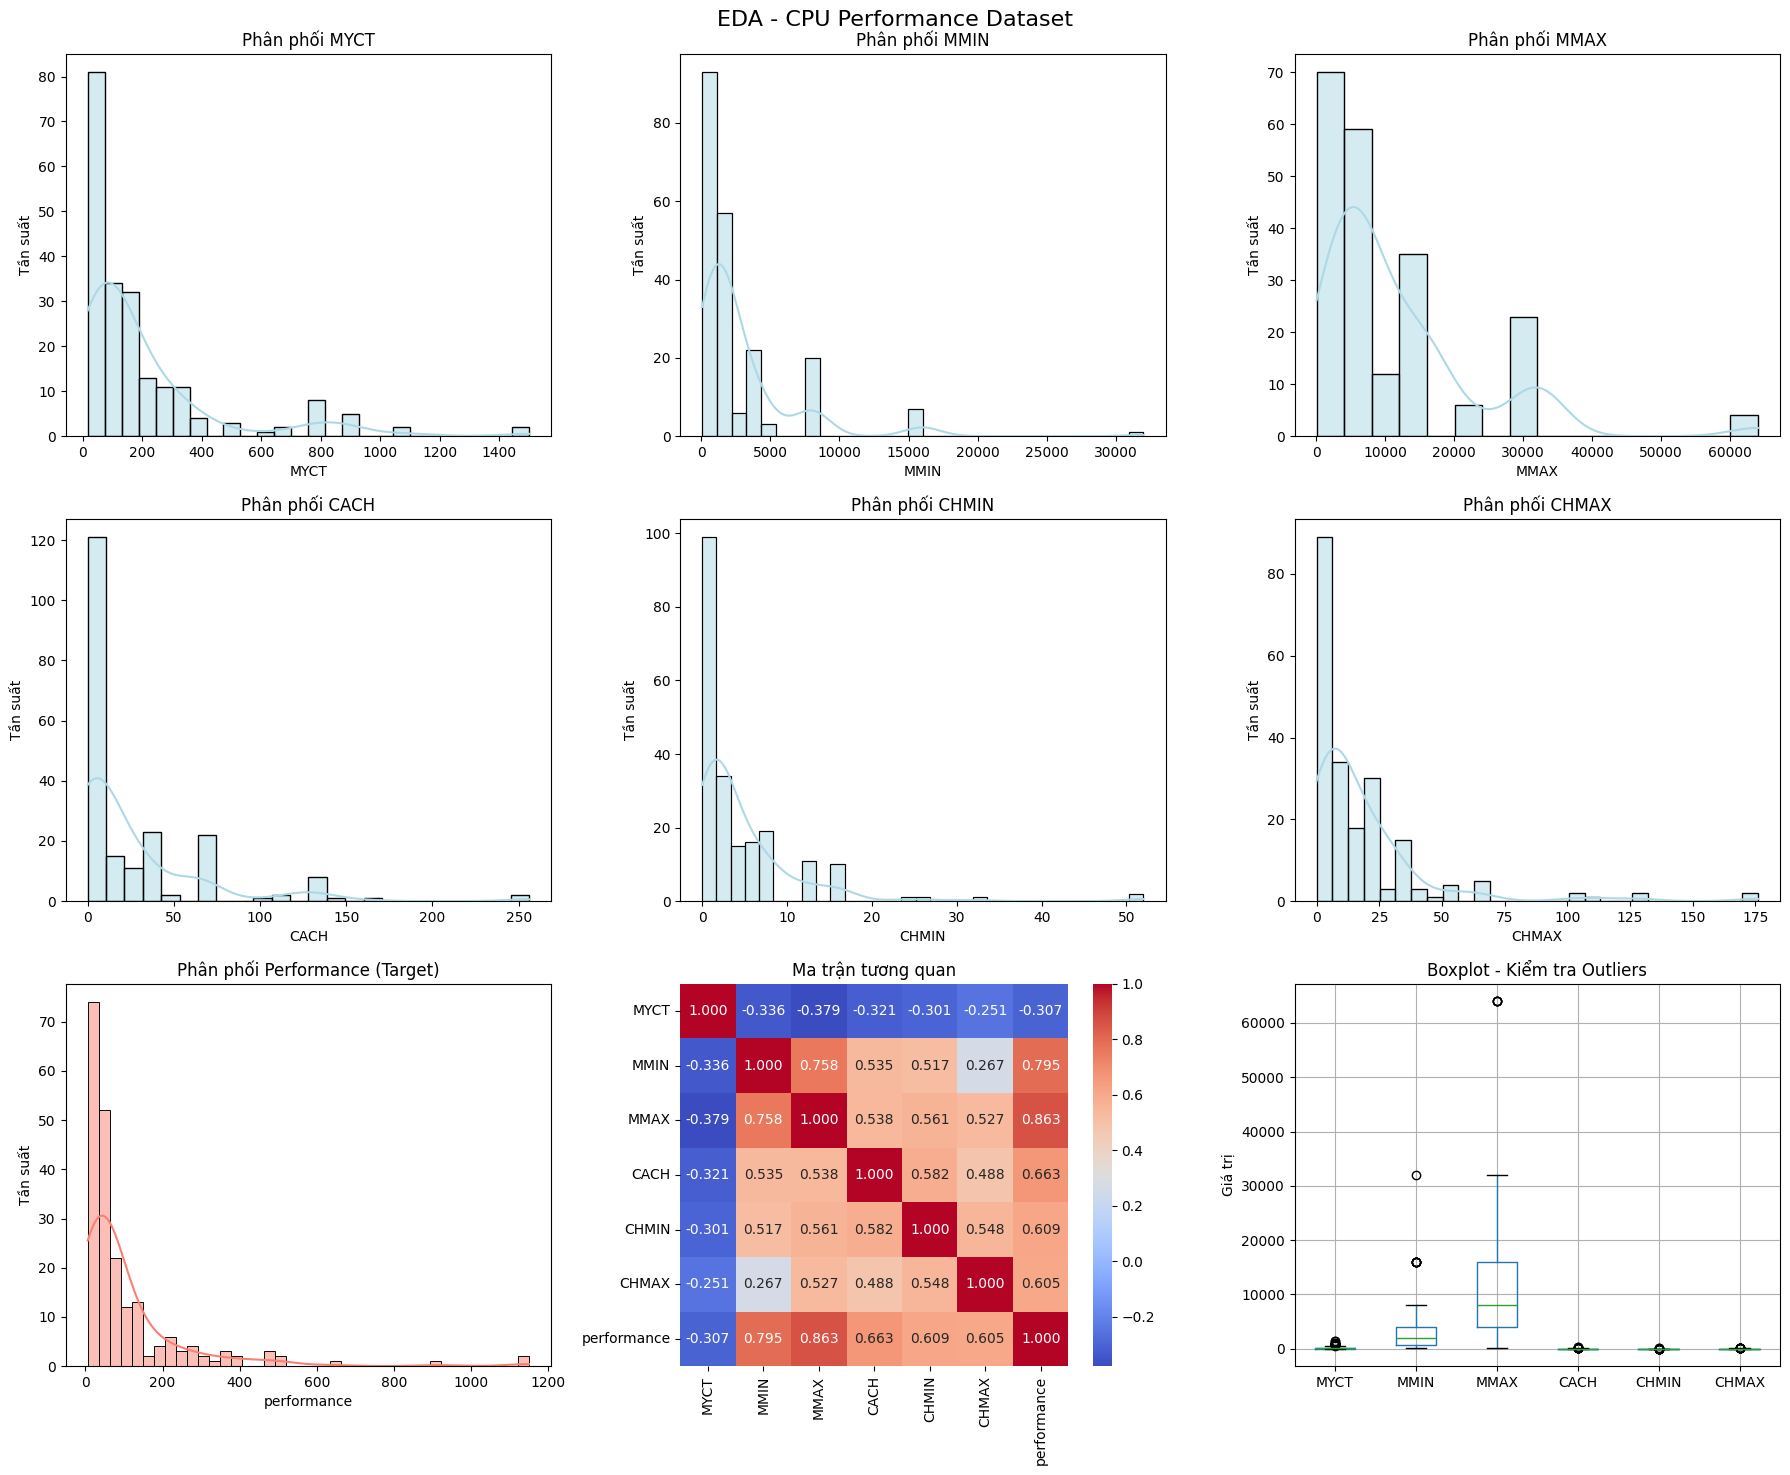

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# 1-6. Histogram của các đặc trưng
for i, col in enumerate(cpu_feature_names):
    sns.histplot(cpu_df[col], kde=True, ax=axes[i], color='lightblue')
    axes[i].set_title(f"Phân phối {col}")
    axes[i].set_ylabel("Tần suất")

# 7. Histogram của target
sns.histplot(cpu_df["performance"], kde=True, ax=axes[6], color='salmon')
axes[6].set_title("Phân phối Performance (Target)")
axes[6].set_ylabel("Tần suất")

# 8. Ma trận tương quan
correlation_matrix_cpu = cpu_df.corr()
sns.heatmap(correlation_matrix_cpu, annot=True, fmt=".3f", cmap='coolwarm', ax=axes[7])
axes[7].set_title("Ma trận tương quan")

# 9. Boxplot để kiểm tra outliers
cpu_df.boxplot(column=cpu_feature_names, ax=axes[8])
axes[8].set_title("Boxplot - Kiểm tra Outliers")
axes[8].set_ylabel("Giá trị")

plt.suptitle("EDA - CPU Performance Dataset", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("02_EDA_CPU.png", dpi=300, bbox_inches="tight")
plt.show()

## Chia dữ liệu

In [10]:
# Chia dữ liệu
X_train_cpu, X_test_cpu, y_train_cpu, y_test_cpu = train_test_split(
    cpu_X, cpu_y, test_size=0.2, random_state=42
)

print("Train:", X_train_cpu.shape)
print("Test :", X_test_cpu.shape)

Train: (167, 6)
Test : (42, 6)


## Chuẩn hóa dữ liệu

In [11]:
# Chuẩn hóa dữ liệu
scaler_cpu = StandardScaler()

X_train_cpu_scaled = scaler_cpu.fit_transform(X_train_cpu)
X_test_cpu_scaled = scaler_cpu.transform(X_test_cpu)

## Xây dựng mô hình Decision Tree Regression

In [12]:
# Xây dựng mô hình Decision Tree Regression
dt_regressor = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=5,
    random_state=42
)

# Huấn luyện
dt_regressor.fit(X_train_cpu_scaled, y_train_cpu)

DecisionTreeRegressor(max_depth=5, random_state=42)

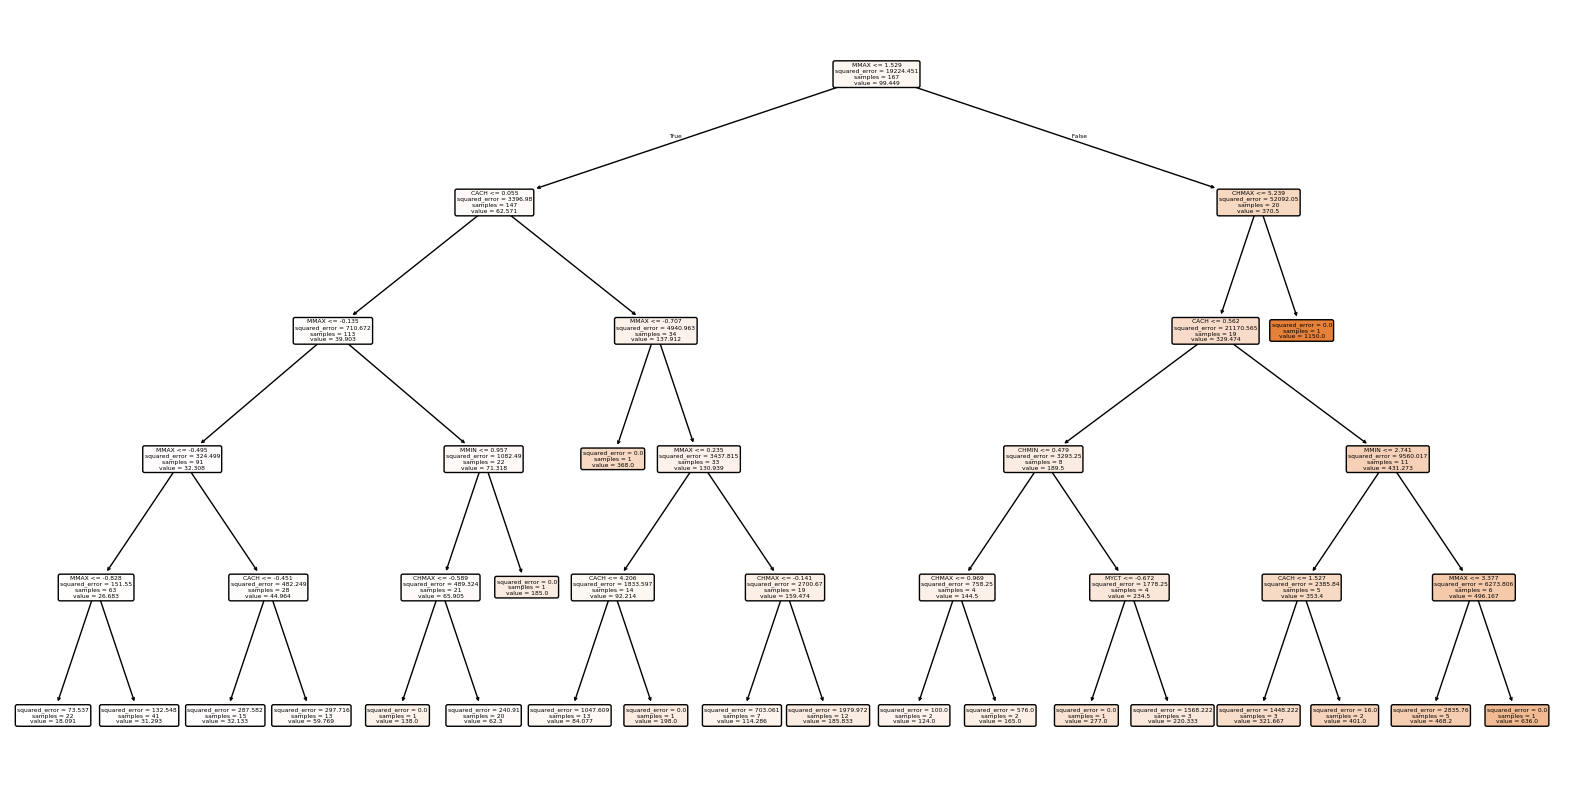

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_regressor, feature_names=cpu_feature_names, filled=True, rounded=True)
plt.show()

## Dự đoán

In [14]:
# Dự đoán
y_pred_cpu = dt_regressor.predict(X_test_cpu_scaled)

## Đánh giá

In [15]:
# Đánh giá
mse = mean_squared_error(y_test_cpu, y_pred_cpu)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_cpu - y_pred_cpu))
r2 = r2_score(y_test_cpu, y_pred_cpu)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 8849.5913
RMSE: 94.0723
MAE: 41.3971
R²: 0.8262


## Đánh giá trên tập Train và Test

In [16]:
train_r2 = r2_score(y_train_cpu, dt_regressor.predict(X_train_cpu_scaled))
test_r2 = r2_score(y_test_cpu, y_pred_cpu)

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")

if train_r2 > test_r2 + 0.1:
    print("Nhận xét: Mô hình có dấu hiệu Overfitting.")
else:
    print("Nhận xét: Mô hình có độ tổng quát hóa khá tốt.")

Train R²: 0.9729
Test  R²: 0.8262
Nhận xét: Mô hình có dấu hiệu Overfitting.


## So sánh giá trị thực tế và dự đoán

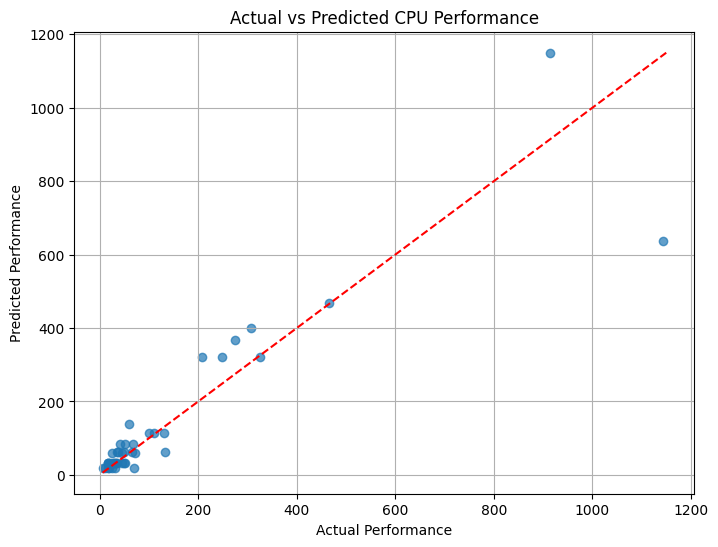

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_cpu,
    y_pred_cpu,
    alpha=0.7
)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted CPU Performance")

# Vẽ đường y = x
xmin = min(y_test_cpu.min(), y_pred_cpu.min())
xmax = max(y_test_cpu.max(), y_pred_cpu.max())
plt.plot([xmin, xmax], [xmin, xmax], color='red', linestyle='--')

plt.grid(True)
plt.show()

## Dự đoán cho CPU mới

In [18]:
new_cpu = [[125, 256, 6000, 256, 16, 128]]

# Cần chuẩn hóa dữ liệu mới trước khi dự đoán
new_cpu_scaled = scaler_cpu.transform(new_cpu)
prediction = dt_regressor.predict(new_cpu_scaled)

print(f"CPU Relative Performance dự đoán: {prediction[0]:.2f}")

CPU Relative Performance dự đoán: 198.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
